# BraTS with 3D MRIs

Initial implementation assumptions:

- mask will be binary disregarding GD-enhancing tumor (ET), the peritumoral edema (ED), and necrotic and non-enhancing tumor core (NCR/NET).
- MRI slices will be treated as 'stand-alone'.

In [3]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import nibabel as nib
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Data
training_data_path = "../data/raw/brats_nii/training"
validation_data_path = "../data/raw/brats_nii/validation"
preprocessed_data_path = "..data/preprocessed/brats_nii"
slices_per_mri = 155 # For all MRIs the total slices is the same

T1CE_SUFFIX = "_t1ce.nii"
T2_SUFFIX = "_t2.nii"
FLAIR_SUFFIX = "_flair.nii"
SEG_SUFFIX = "_seg.nii"

RAND_SEED = 18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0))

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


## Utils

In [ ]:
# @title Utils

def get_patient_dirs(data_path):
    patient_dirs = []
    for patient_folder in os.listdir(data_path):
        patient_path = os.path.join(data_path, patient_folder)
        if os.path.isdir(patient_path):
            patient_dirs.append(patient_path)
    return patient_dirs

def normalize_channel(img):
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min == 0:
        return torch.zeros_like(img)
    return (img - img_min) / (img_max - img_min)

def visualize_random_batch_from_dataset(dataset, n=6, rand_seed=None, show_mask=True):
    if rand_seed is not None:
        random.seed(rand_seed)
        torch.manual_seed(rand_seed)
    
    start_idx = random.randint(0, len(dataset)//2)
    indices = [start_idx+(i*100) for i in range(n)]
    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 5, rows * 5))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]  # img: (3, H, W), mask: (H, W)

        t1ce_norm = normalize_channel(img[0])
        t2_norm = normalize_channel(img[1])
        flair_norm = normalize_channel(img[2])

        rgb_img = torch.stack([t1ce_norm, t2_norm, flair_norm], dim=0)  # (3, H, W)
        rgb_img_np = rgb_img.permute(1, 2, 0).numpy()  # (H, W, 3)
        mask_np = mask.numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(rgb_img_np, origin='lower')
        if show_mask:
            plt.imshow(mask_np, cmap='gray', alpha=0.6, origin='lower')
        plt.axis("off")
        plt.title(f"Sample {idx}")

    plt.tight_layout()
    plt.show()

def visualize_random_batch_from_raw(data_path, n=3, slice_index=50, rand_seed=None):
    if rand_seed is not None:
        random.seed(rand_seed)

    patient_dirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    selected_patients = random.sample(patient_dirs, n)

    fig, axes = plt.subplots(n, 3, figsize=(18, 6 * n))

    if n == 1:
        axes = [axes]

    for i, patient_id in enumerate(selected_patients):
        path = os.path.join(data_path, patient_id, patient_id)

        t1ce = nib.load(path + T1CE_SUFFIX).get_fdata()
        t2 = nib.load(path + T2_SUFFIX).get_fdata()
        flair = nib.load(path + FLAIR_SUFFIX).get_fdata()
        seg = nib.load(path + SEG_SUFFIX).get_fdata()

        t1ce_slice = t1ce[:, :, slice_index]
        t2_slice = t2[:, :, slice_index]
        flair_slice = flair[:, :, slice_index]
        seg_slice = seg[:, :, slice_index]

        t1ce_norm = normalize_channel(t1ce_slice)
        t2_norm = normalize_channel(t2_slice)
        flair_norm = normalize_channel(flair_slice)

        rgb_img = torch.from_numpy(np.stack([t1ce_norm, t2_norm, flair_norm], axis=-1)).float()
        seg_mask = (torch.from_numpy(seg_slice) > 0).float()

        ax1, ax2, ax3 = axes[i]

        ax1.imshow(rgb_img.permute(1, 0, 2).numpy(), origin='lower')
        ax1.set_title(f'{patient_id}: RGB Composite')
        ax1.axis('off')

        ax2.imshow(seg_mask.T.numpy(), cmap='gray', origin='lower')
        ax2.set_title(f'{patient_id}: Segmentation Mask (Slice {slice_index})')
        ax2.axis('off')

        ax3.imshow(rgb_img.permute(1, 0, 2).numpy(), origin='lower')
        ax3.imshow(seg_mask.T.numpy(), cmap='gray', alpha=0.4, origin='lower')
        ax3.set_title(f'{patient_id}: Overlay')
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

## Preprocessing

In [4]:
def normalize_volume(volume):
    # Z-score norm
    mean = np.mean(volume)
    std = np.std(volume)
    if std == 0:
        return np.zeros_like(volume)
    return (volume - mean) / std

def preprocess_brats_to_pt(data_path, output_path):
    os.makedirs(output_path, exist_ok=True)
    patient_dirs = get_patient_dirs(data_path)

    for patient_dir in tqdm(patient_dirs, desc="Preprocessing"):
        basename = os.path.basename(patient_dir)

        t1ce = nib.load(os.path.join(patient_dir, basename + T1CE_SUFFIX)).get_fdata()
        t2   = nib.load(os.path.join(patient_dir, basename + T2_SUFFIX)).get_fdata()
        flair = nib.load(os.path.join(patient_dir, basename + FLAIR_SUFFIX)).get_fdata()
        seg  = nib.load(os.path.join(patient_dir, basename + SEG_SUFFIX)).get_fdata()

        if not (t1ce.shape == t2.shape == flair.shape == seg.shape):
            print(f"Skipping inconsistent patient: {basename}")
            continue

        # Normalize and stack
        t1ce = normalize_volume(t1ce)
        t2 = normalize_volume(t2)
        flair = normalize_volume(flair)

        image_tensor = torch.from_numpy(np.stack([t1ce, t2, flair], axis=0)).float()  # (3, H, W, D)
        mask_tensor = torch.from_numpy((seg > 0).astype(np.float32))  # (H, W, D)

        torch.save({
            'image': image_tensor,
            'mask': mask_tensor
        }, os.path.join(output_path, f"{basename}.pt"))

preprocess_brats_to_pt(training_data_path, preprocessed_data_path)

Preprocessing: 100%|█████████████████████████████████████████████████████████████████| 369/369 [05:43<00:00,  1.07it/s]


## Dataset creation and loader

In [41]:
class LazyBraTSTiffDataset(Dataset):
    def __init__(self, data_path, slices_size, lazy_chunk_size=30):
        self.data_path = data_path
        self.files = [f for f in os.listdir(data_path) if f.endswith('.pt')]
        random.shuffle(self.files)
        self.data_size = len(self.files)
        self.slices_size = slices_size
        self.total_image_size = self.data_size*self.slices_size
        
        self.data = {}
        self.chunk_size = lazy_chunk_size
        self.chunk_start = 0
        self.chunk_end = lazy_chunk_size

        self._load_chunk()

    def __len__(self):
        return self.total_image_size

    def __iter__(self):
        for idx in range(self.total_image_size):
            yield self[idx]
    
    def __getitem__(self, idx):
        if idx not in self.data:
            if idx >= self.total_image_size:
                raise ValueError(f"index {idx} not valid for length {self.total_image_size}")
            self._move_chunk(idx)
            self._load_chunk()
        return self.data[idx]

    def _move_chunk(self, idx):
        mri_from_slice = idx // self.slices_size
        self.chunk_start = mri_from_slice
        self.chunk_end = min(mri_from_slice + self.chunk_size, self.data_size)

    def _load_chunk(self):
        self.data.clear()
        for patient_idx in range(self.chunk_start, self.chunk_end):
            data = torch.load(os.path.join(self.data_path, self.files[patient_idx]), map_location='cpu', weights_only=False)

            start_slice_idx = patient_idx * self.slices_size
            for i in range(self.slices_size):
                image = data['image'][:, :, :, i]
                mask = data['mask'][:, :, i]
                self.data[start_slice_idx + i] = (image, mask)

In [42]:
dataset = LazyBraTSTiffDataset("../data/preprocessed/brats_nii/", 155)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Shuffling is done in dataset

In [46]:
a = 0
for batch in tqdm(dataloader, "dataloader"):
    a += 1
print(a)

dataloader: 100%|█████████████████████████████████████████████████████████████████| 7150/7150 [01:03<00:00, 112.99it/s]

7150


## Visualizations

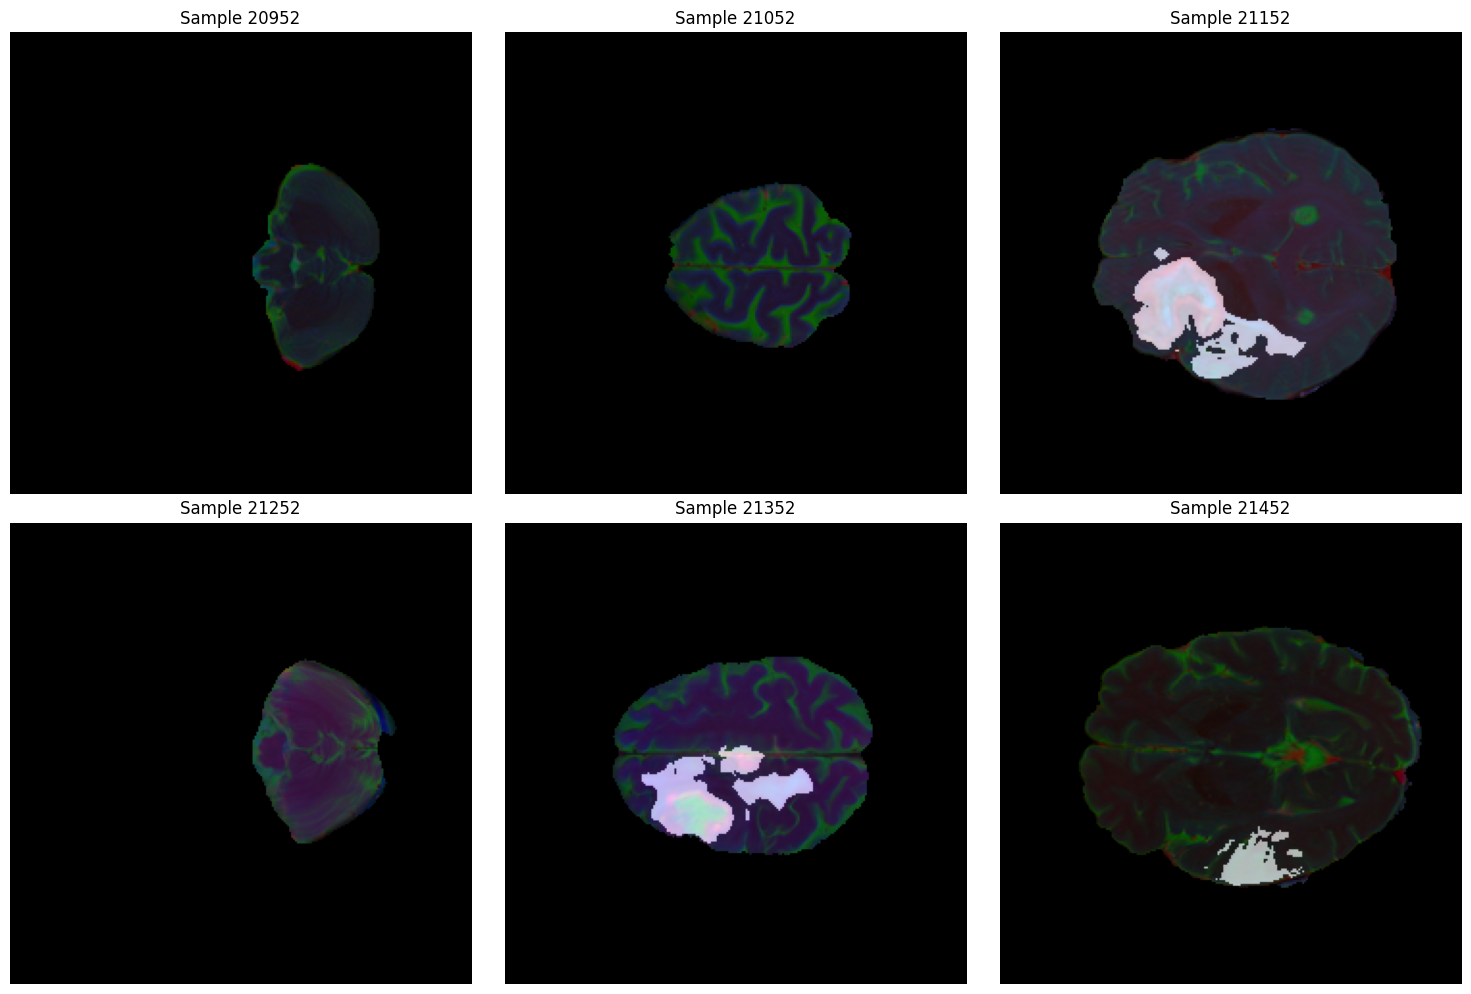

In [91]:
# From dataset
visualize_random_batch_from_dataset(dataset, n=6, rand_seed=42, show_mask=True)

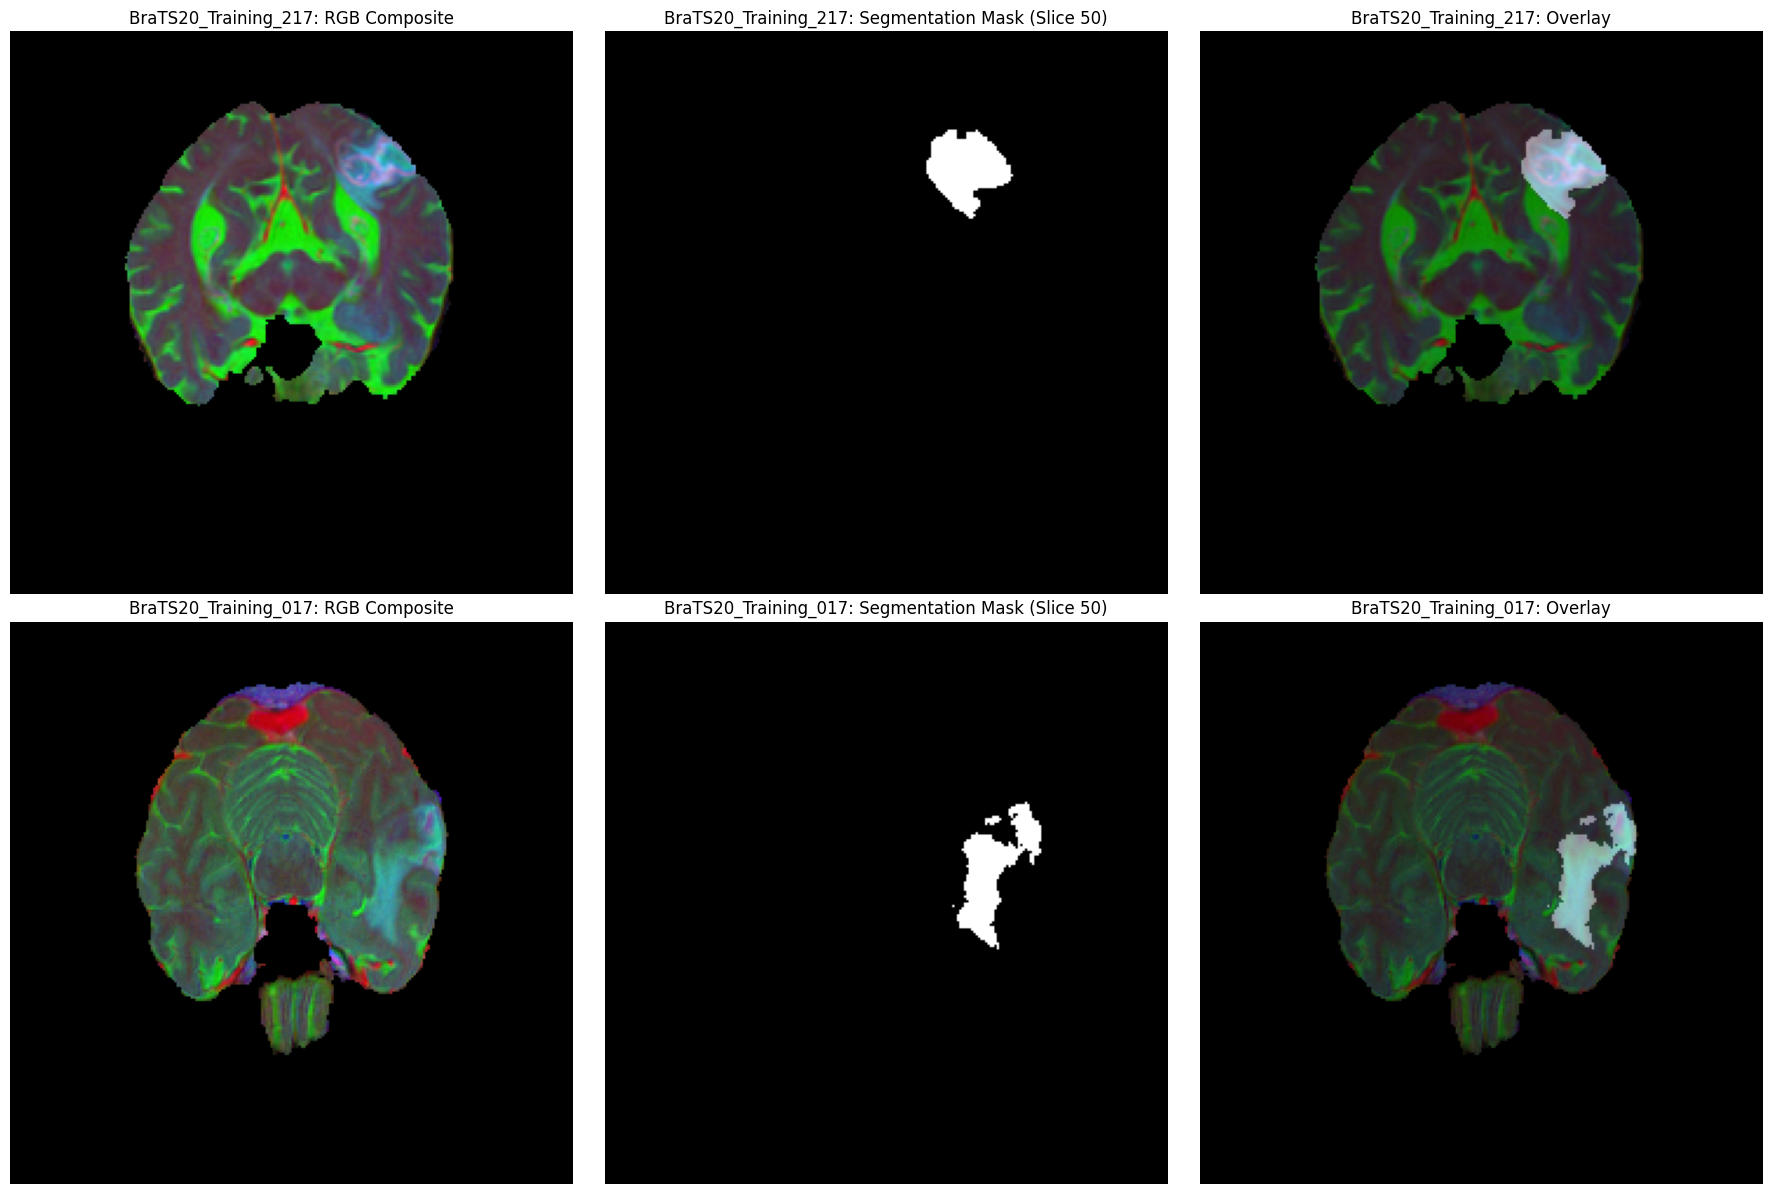

In [89]:
# Raw
visualize_random_batch_from_raw("../data/raw/brats_nii/training", n=2)

## Model training